# Lloyd QPE: Unitary vs Dynamic IQFT

Comparison of **Lloyd with unitary IQFT** vs **Lloyd with dynamic IQFT** from [arXiv:1910.11696](https://arxiv.org/abs/1910.11696).

| Method | Paper | Implementation |
|--------|-------|----------------|
| Lloyd with unitary IQFT | Sec. II-C, Fig. 9 | `method="lloyd"` — unitary IQFT, measure at end |
| Lloyd with dynamic IQFT | Fig. 11 | `method="lloyd_semclassical"` — MCM + `if_test` feed-forward |

Both use **n ancilla qubits** and phase kickback (not single-ancilla iterative QPE).

Paper spot-check: **φ = 11/16 = 0.1011₂** on |1⟩ (Sec. III).


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

from qiskit import transpile
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2

from qsp_core import profile_circuit
from dynamic_qpe import (
    expected_bits,
    build_lloyd_phase_qpe_circuit,
    estimate_phase_from_counts,
)

LLOYD_METHODS = ["lloyd", "lloyd_semclassical"]
METHOD_LABELS = {
    "lloyd": "lloyd with unitary IQFT",
    "lloyd_semclassical": "lloyd with dynamic IQFT",
}

# --- demo parameters (notebook-owned) ---
PAPER_BITS = 4
PAPER_DEMO_PHI = 11.0 / 16.0  # φ = 0.1011₂ (paper Sec. III)
TARGET_BITS = expected_bits(PAPER_DEMO_PHI, PAPER_BITS)
SHOTS = 5000
SEED = 42


def build_lloyd_qc(method: str, n_bits: int = PAPER_BITS, phi: float = PAPER_DEMO_PHI):
    return build_lloyd_phase_qpe_circuit(n_bits, method=method, phi=phi)


sim_ideal = AerSimulator(method="statevector")

service = QiskitRuntimeService(name="YONSEI-SKQD")
backend = service.backend("ibm_yonsei")
backend_sim = AerSimulator().from_backend(backend)
pm = generate_preset_pass_manager(
    target=backend_sim.target,
    optimization_level=3,
    seed_transpiler=SEED,
    layout_method="sabre",
)
print(backend_sim)
print(f"Target: φ={PAPER_DEMO_PHI:.4f}  bits={TARGET_BITS}")


AerSimulator('aer_simulator_from(ibm_yonsei)'
             noise_model=<NoiseModel on ['measure', 'id', 'sx', 'ecr', 'x', 'reset']>)
Target: φ=0.6875  bits=1011


## 1. Ideal comparison — φ = 11/16

Sec. III: `φ = 1/2 + 1/8 + 1/16 = 0.1011` on |1⟩. Lloyd with unitary IQFT and Lloyd with dynamic IQFT should both peak at bitstring `1011`.


In [2]:
paper_rows = []
for method in LLOYD_METHODS:
    qc = build_lloyd_qc(method)
    counts = sim_ideal.run(transpile(qc, sim_ideal), shots=4096).result().get_counts()
    phi, prob, bits = estimate_phase_from_counts(counts, PAPER_BITS)
    ok = bits == TARGET_BITS
    paper_rows.append(dict(method=method, bits=bits, phi=phi, prob=prob, ok=ok))
    print(
        f"{METHOD_LABELS[method]:32s}  bits={bits}  φ={phi:.4f}  P={prob:.3f}  "
        f"{'OK' if ok else 'miss'}"
    )

assert all(r["ok"] for r in paper_rows)


lloyd with unitary IQFT           bits=1011  φ=0.6875  P=1.000  OK
lloyd with dynamic IQFT           bits=1011  φ=0.6875  P=1.000  OK


## 2. Resource profile & circuit diagrams

Fig. 11: modified Lloyd replaces controlled-Rz in IQFT with mid-circuit measure + `if_test` `P` gates (dynamic circuit).



LLOYD WITH UNITARY IQFT
  logical: {'depth': 7, 'depth_2q': 4, 'n_2q': 0, 'n_mcm': 4, 'n_reset': 0, 'n_if_else': 0}
  ISA:     {'depth': 102, 'depth_2q': 26, 'n_2q': 29, 'n_mcm': 4, 'n_reset': 0, 'n_if_else': 0}

LLOYD WITH DYNAMIC IQFT
  logical: {'depth': 13, 'depth_2q': 4, 'n_2q': 0, 'n_mcm': 4, 'n_reset': 0, 'n_if_else': 6}
  ISA:     {'depth': 54, 'depth_2q': 10, 'n_2q': 10, 'n_mcm': 4, 'n_reset': 0, 'n_if_else': 6}


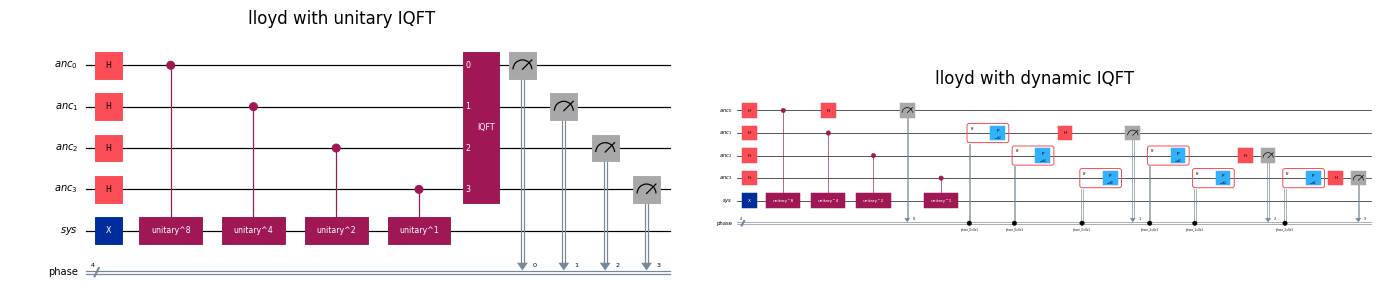

In [3]:
for method in LLOYD_METHODS:
    qc = build_lloyd_qc(method)
    logical = profile_circuit(qc)
    isa = profile_circuit(pm.run(qc))
    print(f"\n{METHOD_LABELS[method].upper()}")
    print(f"  logical: {logical}")
    print(f"  ISA:     {isa}")

fig, axes = plt.subplots(1, 2, figsize=(14, 3))
for ax, method in zip(axes, LLOYD_METHODS):
    qc = build_lloyd_qc(method)
    qc.draw("mpl", ax=ax, fold=-1)
    ax.set_title(METHOD_LABELS[method])
plt.tight_layout()


## 3. Noisy vs ideal (ibm_yonsei Aer)

Same φ = 11/16 benchmark: noiseless statevector vs `from_backend(ibm_yonsei)` ISA circuits.


In [4]:
def run_paper_qpe(method, shots, *, use_isa=False):
    qc = build_lloyd_qc(method)
    if use_isa:
        run_qc = pm.run(qc)
        pub = SamplerV2(mode=backend_sim).run([run_qc], shots=shots).result()[0]
        counts = dict(Counter(pub.data.phase.get_bitstrings()))
    else:
        counts = sim_ideal.run(transpile(qc, sim_ideal), shots=shots).result().get_counts()
    phi, prob, bits = estimate_phase_from_counts(counts, PAPER_BITS)
    return dict(method=method, counts=counts, phi=phi, prob=prob, bits=bits, ok=bits == TARGET_BITS)


rows = []
for mode, use_isa in [("ideal", False), ("noisy", True)]:
    for method in LLOYD_METHODS:
        r = run_paper_qpe(method, SHOTS, use_isa=use_isa)
        rows.append({"mode": mode, **r})
        print(
            f"{mode:5s} {METHOD_LABELS[method]:32s}  bits={r['bits']}  φ={r['phi']:.4f}  "
            f"P={r['prob']:.3f}  {'OK' if r['ok'] else 'miss'}"
        )


ideal lloyd with unitary IQFT           bits=1011  φ=0.6875  P=1.000  OK
ideal lloyd with dynamic IQFT           bits=1011  φ=0.6875  P=1.000  OK
noisy lloyd with unitary IQFT           bits=1011  φ=0.6875  P=0.435  OK
noisy lloyd with dynamic IQFT           bits=0011  φ=0.1875  P=0.341  miss


## 4. Summary plot


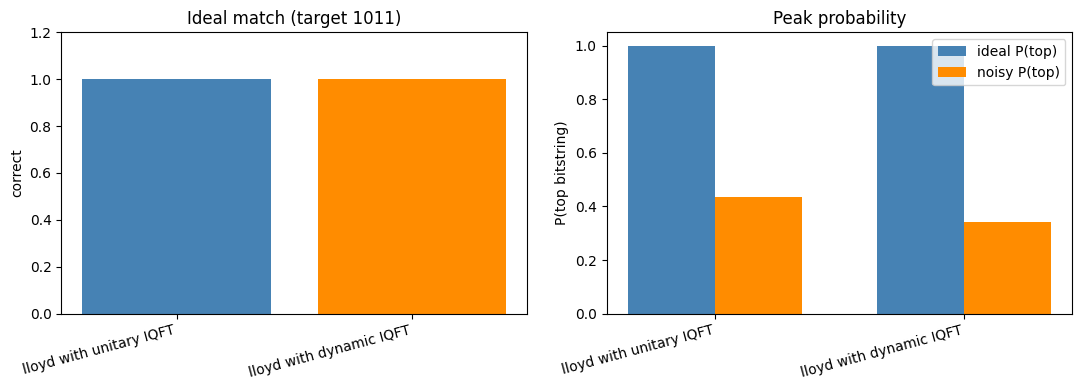

In [5]:
labels = [METHOD_LABELS[m] for m in LLOYD_METHODS]
methods = [r["method"] for r in paper_rows]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ok_ideal = [1 if r["ok"] else 0 for r in paper_rows]
axes[0].bar(range(len(labels)), ok_ideal, color=["steelblue", "darkorange"])
axes[0].set_xticks(range(len(labels)), labels, rotation=15, ha="right")
axes[0].set_ylim(0, 1.2)
axes[0].set_title(f"Ideal match (target {TARGET_BITS})")
axes[0].set_ylabel("correct")

ideal_p = [next(r["prob"] for r in rows if r["mode"] == "ideal" and r["method"] == m) for m in methods]
noisy_p = [next(r["prob"] for r in rows if r["mode"] == "noisy" and r["method"] == m) for m in methods]
x = np.arange(len(methods))
w = 0.35
axes[1].bar(x - w / 2, ideal_p, w, label="ideal P(top)", color="steelblue")
axes[1].bar(x + w / 2, noisy_p, w, label="noisy P(top)", color="darkorange")
axes[1].set_xticks(x, labels, rotation=15, ha="right")
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel("P(top bitstring)")
axes[1].set_title("Peak probability")
axes[1].legend()
plt.tight_layout()


## 5. Takeaways

- **Lloyd with unitary IQFT (Fig. 9)** — n ancillas, unitary inverse QFT, single measurement block at the end (`n_if_else=0`).
- **Lloyd with dynamic IQFT (Fig. 11)** — same kickback prefix; IQFT replaced by low-to-high H → measure → `if_test` P on higher qubits (`n_if_else>0`, dynamic circuit).
- On **ideal** sim both recover φ = 11/16; on **noisy** hardware the unitary IQFT path is often more robust at large n, while the dynamic variant can win at smaller ancilla width.

Code: `src/dynamic_iqpe.py` (`build_lloyd_phase_qpe_circuit`, `_append_semclassical_iqft`).


In [6]:
# Optional: real hardware (DD off for dynamic circuits)
# sampler_hw = SamplerV2(mode=backend)
# sampler_hw.options.dynamical_decoupling.enable = False
# qc = build_lloyd_qc("lloyd_semclassical")
# job = sampler_hw.run([pm.run(qc)], shots=SHOTS)
# print(job.job_id())


## 6. Noisy grid — ancilla bits × phase

Sweep **phase-register width** (ancilla qubits) and target **φ ∈ [0, 1)** on `ibm_yonsei` noisy Aer (ISA transpiled).

- **X-axis:** ancilla bits (`N_BITS_GRID`)
- **Y-axis:** φ over the full period (`PHI_GRID`, uniform on `[0, 1)`)
- **Color:** `P(correct bitstring)` under noise (shared **viridis** scale, side-by-side)


In [7]:
# grid config (notebook-owned)
N_BITS_GRID = np.array([3, 4, 5, 6, 7, 8, 9, 10])
PHI_RESOLUTION = 64  # φ = 0, 1/128, …, 127/128  (full [0, 1) range)
PHI_GRID = np.arange(PHI_RESOLUTION) / PHI_RESOLUTION
GRID_SHOTS = 2000


def run_noisy_lloyd(n_bits: int, phi: float, method: str, shots: int = GRID_SHOTS):
    target = expected_bits(phi, n_bits)
    qc = build_lloyd_qc(method, n_bits=n_bits, phi=phi)
    run_qc = pm.run(qc)
    counts = backend_sim.run(run_qc, shots=shots).result().get_counts()
    _, prob, bits = estimate_phase_from_counts(counts, n_bits)
    return dict(
        target=target,
        bits=bits,
        prob=prob,
        ok=bits == target,
    )


n_phi, n_n = len(PHI_GRID), len(N_BITS_GRID)
prob_lloyd = np.full((n_phi, n_n), np.nan)
prob_sc = np.full((n_phi, n_n), np.nan)
winner = np.zeros((n_phi, n_n), dtype=int)

for j, n_bits in enumerate(N_BITS_GRID):
    for i, phi in enumerate(PHI_GRID):
        rl = run_noisy_lloyd(n_bits, phi, "lloyd")
        rs = run_noisy_lloyd(n_bits, phi, "lloyd_semclassical")
        prob_lloyd[i, j] = rl["prob"]
        prob_sc[i, j] = rs["prob"]
        if rl["prob"] > rs["prob"] + 1e-6:
            winner[i, j] = 1
        elif rs["prob"] > rl["prob"] + 1e-6:
            winner[i, j] = -1
        if i % 16 == 0:
            print(
                f"n={n_bits} φ={phi:.4f}  unitary P={rl['prob']:.3f}  "
                f"dynamic P={rs['prob']:.3f}  "
                f"winner={'unitary' if winner[i,j]==1 else 'dynamic' if winner[i,j]==-1 else 'tie'}"
            )
print(f"Grid done: {n_phi}×{n_n} points")


n=3 φ=0.0000  unitary P=0.661  dynamic P=0.743  winner=dynamic
n=3 φ=0.2500  unitary P=0.620  dynamic P=0.704  winner=dynamic
n=3 φ=0.5000  unitary P=0.616  dynamic P=0.747  winner=dynamic
n=3 φ=0.7500  unitary P=0.625  dynamic P=0.683  winner=dynamic
n=4 φ=0.0000  unitary P=0.497  dynamic P=0.355  winner=unitary
n=4 φ=0.2500  unitary P=0.475  dynamic P=0.362  winner=unitary
n=4 φ=0.5000  unitary P=0.500  dynamic P=0.347  winner=unitary
n=4 φ=0.7500  unitary P=0.482  dynamic P=0.351  winner=unitary
n=5 φ=0.0000  unitary P=0.401  dynamic P=0.691  winner=dynamic
n=5 φ=0.2500  unitary P=0.365  dynamic P=0.676  winner=dynamic
n=5 φ=0.5000  unitary P=0.385  dynamic P=0.677  winner=dynamic
n=5 φ=0.7500  unitary P=0.338  dynamic P=0.648  winner=dynamic
n=6 φ=0.0000  unitary P=0.090  dynamic P=0.589  winner=dynamic
n=6 φ=0.2500  unitary P=0.091  dynamic P=0.585  winner=dynamic
n=6 φ=0.5000  unitary P=0.094  dynamic P=0.584  winner=dynamic
n=6 φ=0.7500  unitary P=0.085  dynamic P=0.587  winner=

Grid summary: unitary IQFT wins 129, dynamic IQFT wins 383, ties 0


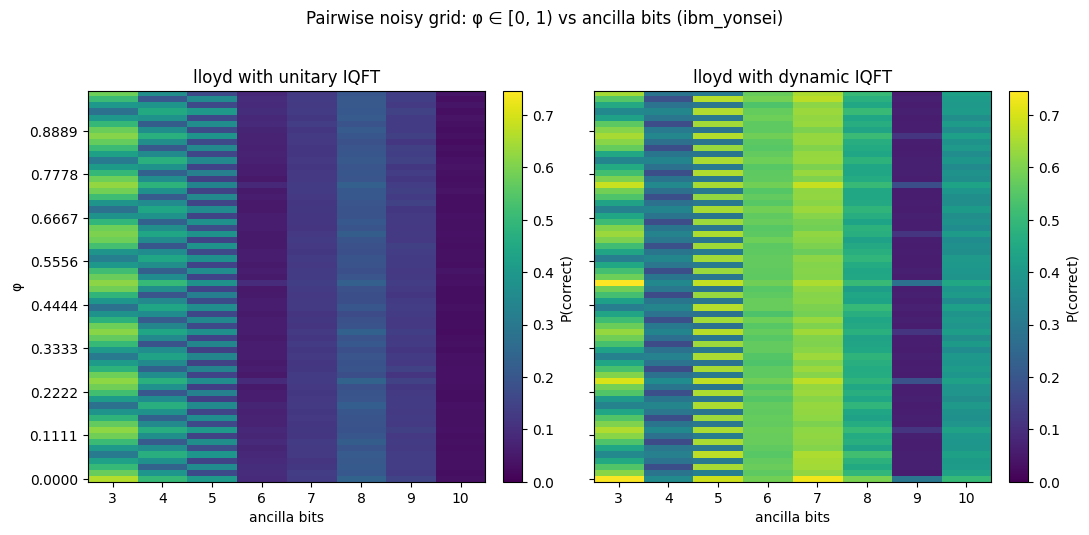

In [8]:
def _grid_extent(x_vals, y_vals):
    """Cell-centered extent for imshow."""
    x, y = np.asarray(x_vals, dtype=float), np.asarray(y_vals, dtype=float)
    dx = (x[1] - x[0]) / 2.0 if len(x) > 1 else 0.5
    dy = (y[1] - y[0]) / 2.0 if len(y) > 1 else 0.5
    return [x[0] - dx, x[-1] + dx, y[0] - dy, y[-1] + dy]


def plot_noisy_lloyd_grid(prob_lloyd, prob_sc, phi_grid, n_bits_grid, *, backend_name="ibm_yonsei"):
    extent = _grid_extent(n_bits_grid, phi_grid)
    vmax = max(float(np.nanmax(prob_lloyd)), float(np.nanmax(prob_sc)), 1e-6)
    panels = [
        (prob_lloyd, METHOD_LABELS["lloyd"]),
        (prob_sc, METHOD_LABELS["lloyd_semclassical"]),
    ]

    fig, axes = plt.subplots(1, 2, figsize=(11, 5.2), sharey=True)
    for ax, (data, title) in zip(axes, panels):
        im = ax.imshow(
            data,
            origin="lower",
            extent=extent,
            aspect="auto",
            cmap="viridis",
            vmin=0.0,
            vmax=vmax,
            interpolation="nearest",
        )
        ax.set_title(title)
        ax.set_xlabel("ancilla bits")
        ax.set_xticks(n_bits_grid)
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label("P(correct)")

    yticks = np.linspace(0, 1, 9, endpoint=False)
    axes[0].set_ylabel("φ")
    axes[0].set_yticks(yticks)
    fig.suptitle(
        f"Pairwise noisy grid: φ ∈ [0, 1) vs ancilla bits ({backend_name})",
        y=1.02,
    )
    fig.tight_layout()
    return fig


fig = plot_noisy_lloyd_grid(
    prob_lloyd,
    prob_sc,
    PHI_GRID,
    N_BITS_GRID,
    backend_name=backend.name,
)

n_lloyd = int(np.sum(winner == 1))
n_sc = int(np.sum(winner == -1))
n_tie = int(np.sum(winner == 0))
print(
    f"Grid summary: unitary IQFT wins {n_lloyd}, dynamic IQFT wins {n_sc}, ties {n_tie}"
)


## 7. Resource scaling vs ancilla qubits

Logical vs **ibm_yonsei ISA** resources for Lloyd with unitary IQFT vs dynamic IQFT (φ fixed to paper demo).

Line style follows `dynamic_cnot_qem.ipynb`: **logical** `o-.` (cyan / magenta), **ISA** `s--` (blue / red).


Profiled 16 circuits on ibm_yonsei


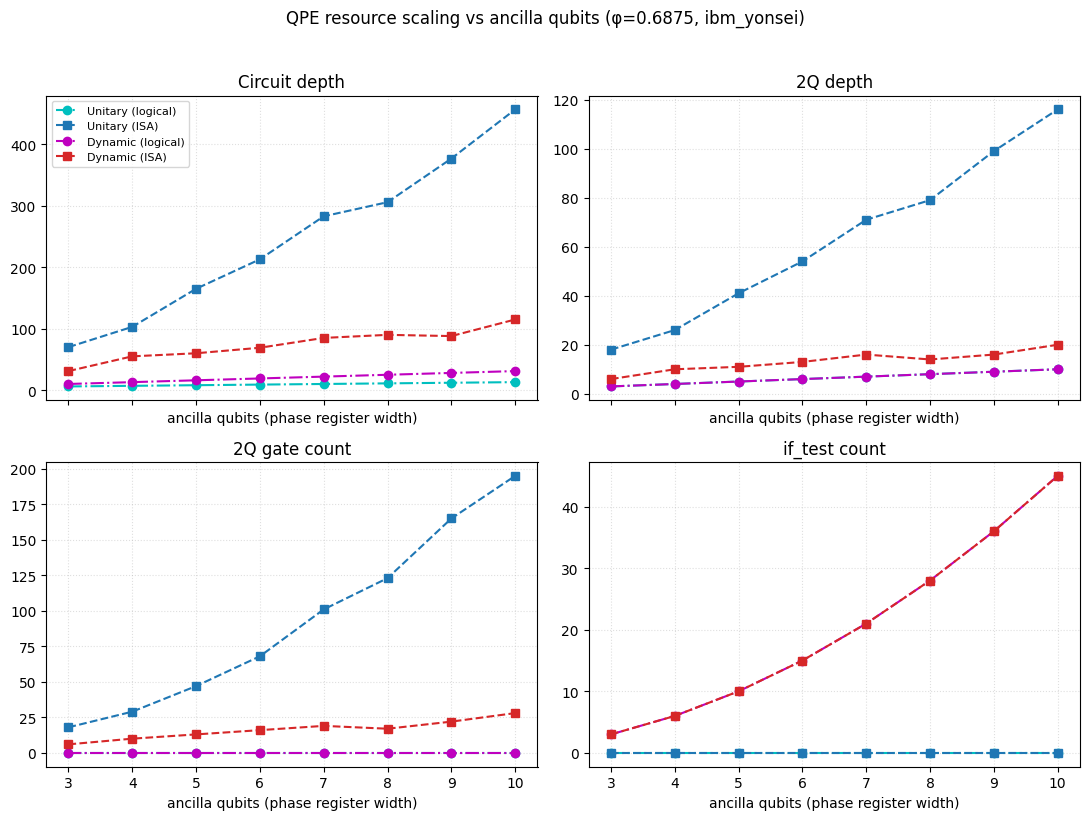

In [10]:
PROFILE_N_BITS = np.array([3, 4, 5, 6, 7, 8, 9, 10])
PROFILE_PHI = PAPER_DEMO_PHI

STYLE = {
    "lloyd": {
        "logical": {"fmt": "o-.", "color": "c", "label": "Unitary (logical)"},
        "isa": {"fmt": "s--", "color": "tab:blue", "label": "Unitary (ISA)"},
    },
    "lloyd_semclassical": {
        "logical": {"fmt": "o-.", "color": "m", "label": "Dynamic (logical)"},
        "isa": {"fmt": "s--", "color": "tab:red", "label": "Dynamic (ISA)"},
    },
}

profile_rows = []
for n_bits in PROFILE_N_BITS:
    for method in LLOYD_METHODS:
        qc = build_lloyd_qc(method, n_bits=n_bits, phi=PROFILE_PHI)
        logical = profile_circuit(qc)
        isa = profile_circuit(pm.run(qc))
        profile_rows.append(
            dict(n_bits=n_bits, method=method, logical=logical, isa=isa)
        )

print(f"Profiled {len(profile_rows)} circuits on {backend.name}")


def series(method, layer, key):
    xs, ys = [], []
    for row in profile_rows:
        if row["method"] != method:
            continue
        xs.append(row["n_bits"])
        ys.append(row[layer][key])
    return np.array(xs), np.array(ys)


METRICS = [
    ("depth", "Circuit depth"),
    ("depth_2q", "2Q depth"),
    ("n_2q", "2Q gate count"),
    ("n_if_else", "if_test count"),
]

fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True)
axes = axes.ravel()

for ax, (key, title) in zip(axes, METRICS):
    for method in LLOYD_METHODS:
        x_log, y_log = series(method, "logical", key)
        x_isa, y_isa = series(method, "isa", key)
        s_log = STYLE[method]["logical"]
        s_isa = STYLE[method]["isa"]
        ax.plot(
            x_log,
            y_log,
            s_log["fmt"],
            color=s_log["color"],
            label=s_log["label"],
        )
        ax.plot(
            x_isa,
            y_isa,
            s_isa["fmt"],
            color=s_isa["color"],
            label=s_isa["label"],
        )
    ax.set_title(title)
    ax.set_xlabel("ancilla qubits (phase register width)")
    ax.set_xticks(PROFILE_N_BITS)
    ax.grid(linestyle=":", alpha=0.4)

axes[0].legend(fontsize=8, loc="upper left")
fig.suptitle(
    f"QPE resource scaling vs ancilla qubits (φ={PROFILE_PHI:.4f}, {backend.name})",
    y=1.02,
)
fig.tight_layout()
